<a href="https://colab.research.google.com/github/azelepou/IntroMachineLearning/blob/main/ML_HW3_AnatolyZelepouga_801236217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Diabetes data: 768 rows, 8 input features
Cancer data: 569 rows, 30 input features
The scaler is fit on the training rows only.
Diabetes: alpha=0.03, lambda=0.00, iterations=2000, loss=0.494646, accuracy=0.7143, precision=0.6087, recall=0.5185, F1=0.5600
Confusion matrix:
 [[82 18]
 [26 28]]


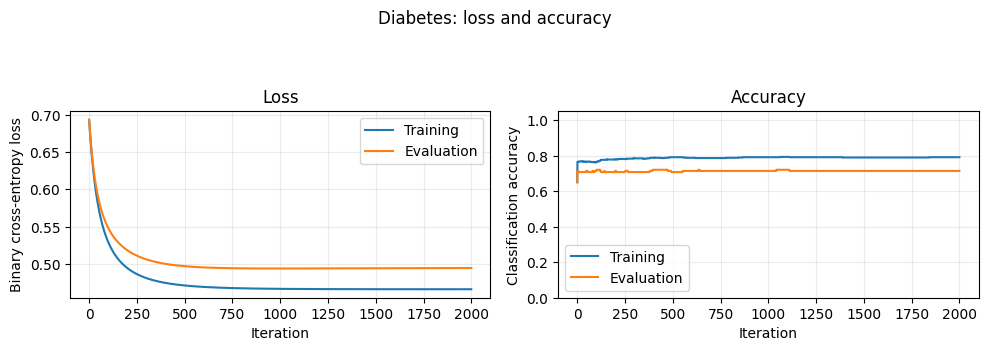

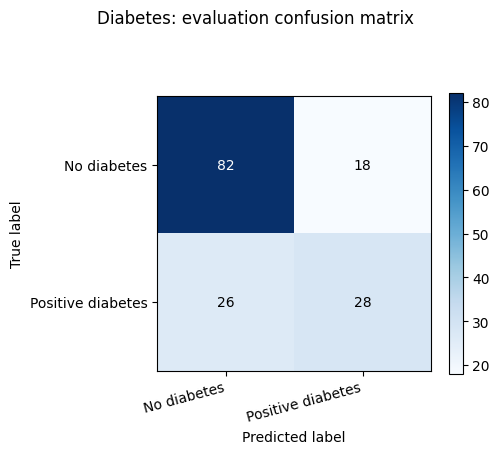

Cancer: alpha=0.05, lambda=0.00, iterations=2000, loss=0.069089, accuracy=0.9825, precision=1.0000, recall=0.9524, F1=0.9756
Confusion matrix:
 [[72  0]
 [ 2 40]]


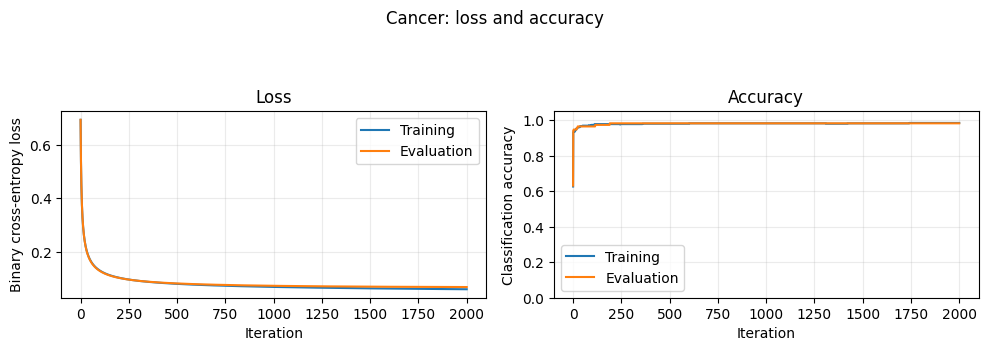

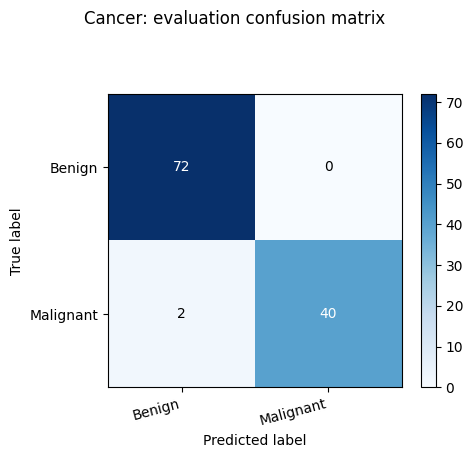

Cancer regularized: alpha=0.10, lambda=1.00, iterations=2000, loss=0.071335, accuracy=0.9825, precision=1.0000, recall=0.9524, F1=0.9756
Confusion matrix:
 [[72  0]
 [ 2 40]]


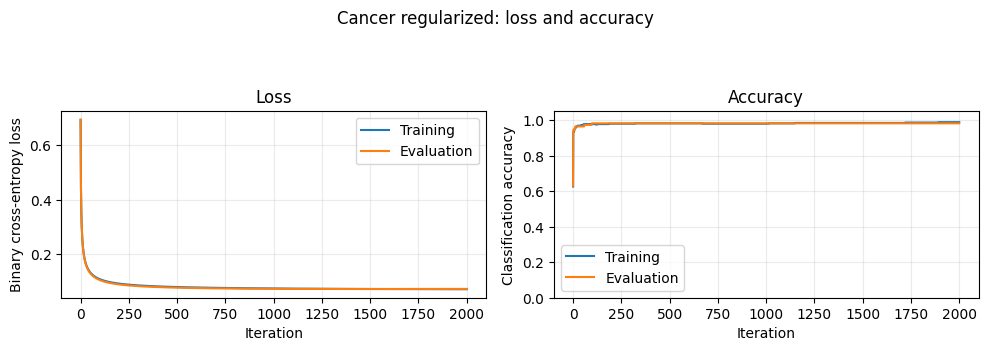

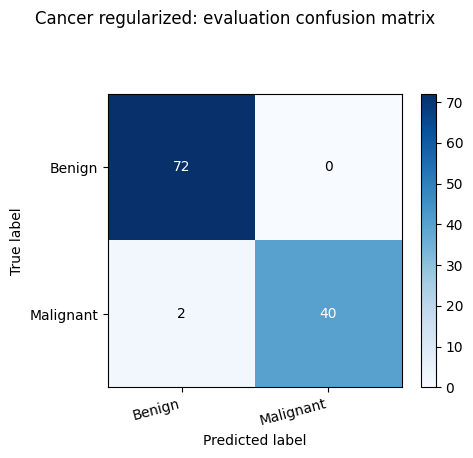

Results and plots were saved in hw3_results/


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


RESULTS = Path("hw3_results")
RESULTS.mkdir(exist_ok=True)
RANDOM_SEED = 42
LEARNING_RATES = [0.01, 0.03, 0.05, 0.10]
MAX_ITERATIONS = 2000
TOLERANCE = 1e-7


def find_csv(words):
    candidates = sorted(Path(".").glob("*.csv"))

    for path in candidates:
        name = path.name.lower()

        if any(word in name for word in words):
            return path

    return None


diabetes_file = find_csv(["diabet"])

if diabetes_file is None:
    try:
        from google.colab import files

        print("Upload the diabetes CSV file (and Cancer_Data.csv if you have it).")
        files.upload()

    except ImportError:
        pass

    diabetes_file = find_csv(["diabet"])


if diabetes_file is None:
    raise FileNotFoundError(
        "Upload the diabetes CSV and run this cell again."
    )


def target_column(frame, preferred):
    names = {
        column.strip().lower(): column
        for column in frame.columns
    }

    for name in preferred:
        if name in names:
            return names[name]

    return frame.columns[-1]


def encode_binary_target(values, positive_words):
    numeric = pd.to_numeric(values, errors="coerce")

    if numeric.notna().all():
        unique = sorted(numeric.unique())

        if len(unique) != 2:
            raise ValueError(
                "The target column must contain two classes."
            )

        if set(unique) == {0, 1}:
            return numeric.to_numpy(dtype=int)

        return (
            numeric == unique[-1]
        ).astype(int).to_numpy()

    text = values.astype(str).str.strip().str.lower()
    positive_words = {
        word.lower()
        for word in positive_words
    }

    known = {
        "0",
        "1",
        "no",
        "yes",
        "false",
        "true",
        "negative",
        "positive",
        "benign",
        "malignant",
        "b",
        "m",
        "healthy",
        "diabetic",
    }

    if text.isin(known).all():
        return text.isin(
            positive_words
        ).astype(int).to_numpy()

    unique = sorted(text.unique())

    if len(unique) != 2:
        raise ValueError(
            "The target column must contain two classes."
        )

    return (
        text == unique[-1]
    ).astype(int).to_numpy()


def numeric_matrix(frame, target):
    inputs = frame.drop(
        columns=[target]
    ).copy()

    drop_columns = []

    for column in inputs.columns:
        name = str(column).strip().lower()

        if (
            name.startswith("unnamed")
            or name in {
                "id",
                "index",
                "sample code",
            }
        ):
            drop_columns.append(column)

    inputs = inputs.drop(
        columns=drop_columns,
        errors="ignore",
    )

    for column in inputs.columns:
        if inputs[column].dtype == object:
            text = inputs[column].astype(str).str.strip().str.lower()

            if set(
                text.dropna().unique()
            ).issubset({"yes", "no"}):
                inputs[column] = text.map(
                    {
                        "no": 0.0,
                        "yes": 1.0,
                    }
                )

    inputs = pd.get_dummies(
        inputs,
        dtype=float,
    )

    inputs = inputs.apply(
        pd.to_numeric,
        errors="coerce",
    )

    inputs = inputs.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    inputs = inputs.fillna(
        inputs.median(
            numeric_only=True
        )
    )

    if inputs.isna().any().any():
        inputs = inputs.fillna(0.0)

    return (
        inputs.to_numpy(dtype=float),
        list(inputs.columns),
    )


def load_diabetes():
    frame = pd.read_csv(diabetes_file)

    frame.columns = [
        str(column).strip()
        for column in frame.columns
    ]

    target = target_column(
        frame,
        [
            "outcome",
            "class",
            "target",
            "diabetes",
            "label",
        ],
    )

    X, columns = numeric_matrix(
        frame,
        target,
    )

    y = encode_binary_target(
        frame[target],
        {
            "1",
            "yes",
            "true",
            "positive",
            "diabetic",
            "diabetes",
        },
    )

    return (
        X,
        y,
        columns,
        [
            "No diabetes",
            "Positive diabetes",
        ],
    )


def load_cancer():
    cancer_file = find_csv(["cancer"])

    if cancer_file is not None:
        frame = pd.read_csv(cancer_file)

        frame.columns = [
            str(column).strip()
            for column in frame.columns
        ]

        target = target_column(
            frame,
            [
                "diagnosis",
                "class",
                "target",
                "label",
                "outcome",
            ],
        )

        X, columns = numeric_matrix(
            frame,
            target,
        )

        y = encode_binary_target(
            frame[target],
            {
                "1",
                "m",
                "malignant",
                "positive",
            },
        )

        return (
            X,
            y,
            columns,
            [
                "Benign",
                "Malignant",
            ],
        )

    dataset = load_breast_cancer()
    X = dataset.data.astype(float)

    # sklearn stores malignant as 0 and benign as 1.
    y = (
        dataset.target == 0
    ).astype(int)

    return (
        X,
        y,
        list(dataset.feature_names),
        [
            "Benign",
            "Malignant",
        ],
    )


def split_and_standardize(X, y):
    X_train, X_eval, y_train, y_eval = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=y,
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_eval = scaler.transform(X_eval)

    X_train = np.column_stack(
        (
            np.ones(len(X_train)),
            X_train,
        )
    )

    X_eval = np.column_stack(
        (
            np.ones(len(X_eval)),
            X_eval,
        )
    )

    return (
        X_train,
        X_eval,
        y_train,
        y_eval,
    )


def sigmoid(values):
    values = np.clip(
        values,
        -40,
        40,
    )

    return 1.0 / (
        1.0 + np.exp(-values)
    )


def loss_value(
    X,
    y,
    theta,
    penalty=0.0,
):
    probabilities = sigmoid(
        X @ theta
    )

    probabilities = np.clip(
        probabilities,
        1e-12,
        1 - 1e-12,
    )

    cross_entropy = -np.mean(
        y * np.log(probabilities)
        + (1 - y)
        * np.log(1 - probabilities)
    )

    weight_cost = (
        penalty
        * np.sum(theta[1:] ** 2)
        / (2 * len(y))
    )

    return float(
        cross_entropy + weight_cost
    )


def logistic_gradient_descent(
    X_train,
    y_train,
    X_eval,
    y_eval,
    alpha,
    penalty=0.0,
):
    theta = np.zeros(
        X_train.shape[1]
    )

    train_loss = [
        loss_value(
            X_train,
            y_train,
            theta,
            penalty,
        )
    ]

    eval_loss = [
        loss_value(
            X_eval,
            y_eval,
            theta,
        )
    ]

    train_accuracy = [
        np.mean(y_train == 0)
    ]

    eval_accuracy = [
        np.mean(y_eval == 0)
    ]

    for iteration in range(MAX_ITERATIONS):
        probabilities = sigmoid(
            X_train @ theta
        )

        gradient = (
            X_train.T
            @ (probabilities - y_train)
            / len(y_train)
        )

        gradient[1:] += (
            penalty
            * theta[1:]
            / len(y_train)
        )

        next_theta = (
            theta - alpha * gradient
        )

        step = np.linalg.norm(
            next_theta - theta
        )

        theta = next_theta

        train_probabilities = sigmoid(
            X_train @ theta
        )

        eval_probabilities = sigmoid(
            X_eval @ theta
        )

        train_predictions = (
            train_probabilities >= 0.5
        ).astype(int)

        eval_predictions = (
            eval_probabilities >= 0.5
        ).astype(int)

        train_loss.append(
            loss_value(
                X_train,
                y_train,
                theta,
                penalty,
            )
        )

        eval_loss.append(
            loss_value(
                X_eval,
                y_eval,
                theta,
            )
        )

        train_accuracy.append(
            np.mean(
                y_train == train_predictions
            )
        )

        eval_accuracy.append(
            np.mean(
                y_eval == eval_predictions
            )
        )

        if step <= TOLERANCE:
            break

    return {
        "theta": theta,
        "alpha": alpha,
        "penalty": penalty,
        "iterations": iteration + 1,
        "train_loss": np.asarray(train_loss),
        "eval_loss": np.asarray(eval_loss),
        "train_accuracy": np.asarray(train_accuracy),
        "eval_accuracy": np.asarray(eval_accuracy),
    }


def choose_best(results):
    return min(
        results,
        key=lambda result: (
            result["eval_loss"][-1],
            result["iterations"],
        ),
    )


def final_metrics(result, X, y):
    probabilities = sigmoid(
        X @ result["theta"]
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    matrix = confusion_matrix(
        y,
        predictions,
        labels=[0, 1],
    )

    return {
        "accuracy": accuracy_score(
            y,
            predictions,
        ),
        "precision": precision_score(
            y,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y,
            predictions,
            zero_division=0,
        ),
        "confusion_matrix": matrix,
    }


def print_result(
    name,
    result,
    metrics,
):
    print(
        f"{name}: "
        f"alpha={result['alpha']:.2f}, "
        f"lambda={result['penalty']:.2f}, "
        f"iterations={result['iterations']}, "
        f"loss={result['eval_loss'][-1]:.6f}, "
        f"accuracy={metrics['accuracy']:.4f}, "
        f"precision={metrics['precision']:.4f}, "
        f"recall={metrics['recall']:.4f}, "
        f"F1={metrics['f1']:.4f}"
    )


def plot_history(
    result,
    title,
    filename,
):
    steps = np.arange(
        len(result["train_loss"])
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 3.5),
    )

    axes[0].plot(
        steps,
        result["train_loss"],
        label="Training",
    )

    axes[0].plot(
        steps,
        result["eval_loss"],
        label="Evaluation",
    )

    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel(
        "Binary cross-entropy loss"
    )
    axes[0].set_title("Loss")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(
        steps,
        result["train_accuracy"],
        label="Training",
    )

    axes[1].plot(
        steps,
        result["eval_accuracy"],
        label="Evaluation",
    )

    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel(
        "Classification accuracy"
    )
    axes[1].set_ylim(
        0,
        1.05,
    )
    axes[1].set_title("Accuracy")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    fig.suptitle(
        title,
        y=0.99,
    )

    fig.tight_layout(
        rect=(0, 0, 1, 0.90)
    )

    fig.savefig(
        RESULTS / filename,
        dpi=220,
    )

    plt.show()
    plt.close(fig)


def plot_confusion(
    result,
    X,
    y,
    labels,
    title,
    filename,
):
    metrics = final_metrics(
        result,
        X,
        y,
    )

    matrix = metrics["confusion_matrix"]

    fig, ax = plt.subplots(
        figsize=(5.2, 4.5)
    )

    image = ax.imshow(
        matrix,
        cmap="Blues",
    )

    fig.colorbar(
        image,
        ax=ax,
    )

    ax.set(
        xticks=[0, 1],
        yticks=[0, 1],
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted label",
        ylabel="True label",
    )

    ax.set_xticklabels(
        labels,
        rotation=15,
        ha="right",
    )

    threshold = (
        matrix.max() / 2
        if matrix.max()
        else 0
    )

    for row in range(2):
        for column in range(2):
            color = (
                "white"
                if matrix[row, column] > threshold
                else "black"
            )

            ax.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
                color=color,
            )

    fig.suptitle(
        title,
        y=0.98,
        fontsize=12,
    )

    fig.tight_layout(
        rect=(0, 0, 1, 0.90)
    )

    fig.savefig(
        RESULTS / filename,
        dpi=220,
    )

    plt.show()
    plt.close(fig)

    return metrics


def run_experiment(
    name,
    X,
    y,
    labels,
    penalty=0.0,
):
    X_train, X_eval, y_train, y_eval = (
        split_and_standardize(X, y)
    )

    trials = []

    for alpha in LEARNING_RATES:
        trials.append(
            logistic_gradient_descent(
                X_train,
                y_train,
                X_eval,
                y_eval,
                alpha,
                penalty,
            )
        )

    result = choose_best(trials)

    train_metrics = final_metrics(
        result,
        X_train,
        y_train,
    )

    eval_metrics = final_metrics(
        result,
        X_eval,
        y_eval,
    )

    print_result(
        name,
        result,
        eval_metrics,
    )

    print(
        "Confusion matrix:\n",
        eval_metrics["confusion_matrix"],
    )

    plot_history(
        result,
        f"{name}: loss and accuracy",
        f"{name.lower().replace(' ', '_')}_history.png",
    )

    plot_confusion(
        result,
        X_eval,
        y_eval,
        labels,
        f"{name}: evaluation confusion matrix",
        f"{name.lower().replace(' ', '_')}_confusion_matrix.png",
    )

    return {
        "name": name,
        "result": result,
        "train_metrics": train_metrics,
        "eval_metrics": eval_metrics,
        "X_train": X_train,
        "X_eval": X_eval,
        "y_train": y_train,
        "y_eval": y_eval,
    }


diabetes_X, diabetes_y, diabetes_columns, diabetes_labels = (
    load_diabetes()
)

cancer_X, cancer_y, cancer_columns, cancer_labels = (
    load_cancer()
)

print(
    f"Diabetes data: {len(diabetes_y)} rows, "
    f"{diabetes_X.shape[1]} input features"
)

print(
    f"Cancer data: {len(cancer_y)} rows, "
    f"{cancer_X.shape[1]} input features"
)

print(
    "The scaler is fit on the training rows only."
)


diabetes = run_experiment(
    "Diabetes",
    diabetes_X,
    diabetes_y,
    diabetes_labels,
)

cancer = run_experiment(
    "Cancer",
    cancer_X,
    cancer_y,
    cancer_labels,
)

cancer_regularized = run_experiment(
    "Cancer regularized",
    cancer_X,
    cancer_y,
    cancer_labels,
    penalty=1.0,
)


summary_rows = []

for experiment in [
    diabetes,
    cancer,
    cancer_regularized,
]:
    result = experiment["result"]
    metrics = experiment["eval_metrics"]

    summary_rows.append(
        {
            "experiment": experiment["name"],
            "alpha": result["alpha"],
            "lambda": result["penalty"],
            "iterations": result["iterations"],
            "training_loss": result["train_loss"][-1],
            "evaluation_loss": result["eval_loss"][-1],
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "true_negative": metrics["confusion_matrix"][0, 0],
            "false_positive": metrics["confusion_matrix"][0, 1],
            "false_negative": metrics["confusion_matrix"][1, 0],
            "true_positive": metrics["confusion_matrix"][1, 1],
        }
    )


pd.DataFrame(summary_rows).to_csv(
    RESULTS / "metrics_summary.csv",
    index=False,
)


coefficient_rows = []

for experiment, columns in [
    (diabetes, diabetes_columns),
    (cancer, cancer_columns),
    (cancer_regularized, cancer_columns),
]:
    theta = experiment["result"]["theta"]

    coefficient_rows.append(
        {
            "experiment": experiment["name"],
            "intercept": theta[0],
            **{
                column: value
                for column, value in zip(
                    columns,
                    theta[1:],
                )
            },
        }
    )


pd.DataFrame(coefficient_rows).to_csv(
    RESULTS / "standardized_coefficients.csv",
    index=False,
)


with (
    RESULTS / "results.txt"
).open("w") as output:
    for row in summary_rows:
        output.write(
            f"{row['experiment']}: "
            f"alpha={row['alpha']:.2f}, "
            f"lambda={row['lambda']:.2f}, "
            f"iterations={row['iterations']}, "
            f"evaluation loss={row['evaluation_loss']:.6f}, "
            f"accuracy={row['accuracy']:.4f}, "
            f"precision={row['precision']:.4f}, "
            f"recall={row['recall']:.4f}, "
            f"F1={row['f1']:.4f}\n"
        )


print(
    f"Results and plots were saved in {RESULTS}/"
)